# Cs-137 Scatter Peak Analysis (03-12, 0 deg, 0 absorb)

This notebook runs a minimal local peak analysis for:

`shared/jlab/Analysis/data/03-12-Cs-137-scatter-0deg-0absorb.Spe`

Workflow:
1. Load spectrum + timing metadata from `.Spe`
2. Rebin channels (default here: 2048 -> 1024)
3. Find candidate peaks
4. Pick one candidate peak index
5. Fit Gaussian + linear background locally
6. Compute net peak rate (counts/s)

In [26]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from analysis_evan import (
    read_spe,
    find_peak_candidates,
    fit_local_peak,
    peak_rate_from_fit,
    gaussian_plus_linear,
)

plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["xtick.labelsize"] = 14
plt.rcParams["ytick.labelsize"] = 14
plt.rcParams["legend.fontsize"] = 14

Loaded: /Users/evankim/Documents/MIT/Spring 2026/8.13/shared/jlab/Analysis/data/03-12-Cs-137-scatter-0deg-0absorb.Spe
Raw channels: 2048
Rebin factor: 4
Channels used in analysis: 512
Live time [s]: 203.0
Real time [s]: 207.0


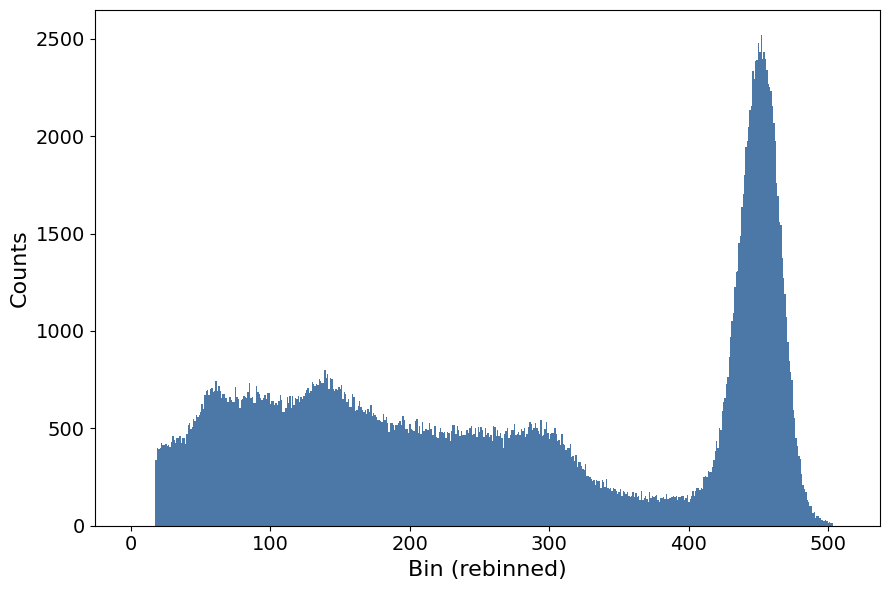

In [27]:
# Use notebook-local pathing
notebook_dir = Path.cwd()
spe_path = notebook_dir / "data" / "03-12-Cs-137-scatter-0deg-0absorb.Spe"

# Match the older analysis scripts: 2048 -> 1024 channels
rebin_factor = 4
sp = read_spe(str(spe_path), rebin_factor=rebin_factor)

print(f"Loaded: {sp.path}")
print(f"Raw channels: {sp.n_channels_raw}")
print(f"Rebin factor: {sp.rebin_factor}")
print(f"Channels used in analysis: {len(sp.counts)}")
print(f"Live time [s]: {sp.live_time_s}")
print(f"Real time [s]: {sp.real_time_s}")

plt.figure()
plt.bar(sp.bins, sp.counts, width=1.0, color="#4C78A8")
plt.xlabel("Bin (rebinned)")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()

Candidate peaks:
[0] bin=85.0, height=731.0, prominence=80.0
[1] bin=139.0, height=798.0, prominence=216.0
[2] bin=231.0, height=515.0, prominence=82.0
[3] bin=260.0, height=514.0, prominence=77.0
[4] bin=294.0, height=545.0, prominence=145.0
[5] bin=452.0, height=2522.0, prominence=2401.0


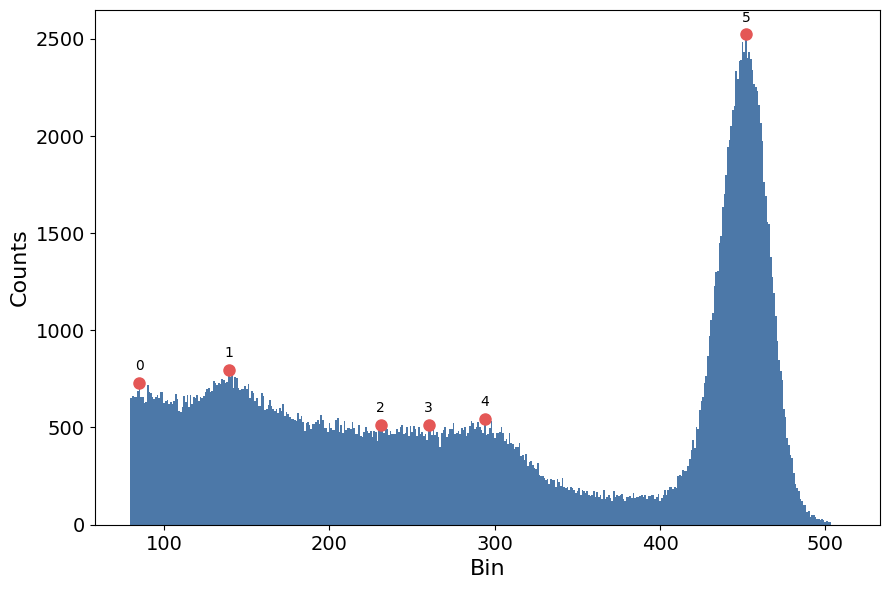

In [28]:
# Candidate-finding pass (tune parameters if needed)
min_bin = 80
cands = find_peak_candidates(
    sp.bins,
    sp.counts,
    min_bin=min_bin,
    prominence=None,
    height=None,
    distance=20,
    max_peaks=10,
)

print("Candidate peaks:")
for i, (b, h, p) in enumerate(zip(cands.candidate_bins, cands.candidate_heights, cands.candidate_prominences)):
    print(f"[{i}] bin={b:.1f}, height={h:.1f}, prominence={p:.1f}")

mask = sp.bins >= min_bin
bins_use = sp.bins[mask]
counts_use = sp.counts[mask]

plt.figure()
plt.bar(bins_use, counts_use, width=1.0, color="#4C78A8")
if len(cands.candidate_bins) > 0:
    plt.plot(cands.candidate_bins, cands.candidate_heights, "o", color="#E45756", ms=8)
    for i, (xb, yb) in enumerate(zip(cands.candidate_bins, cands.candidate_heights)):
        plt.text(xb, yb + 0.02 * np.max(counts_use), str(i), ha="center", va="bottom")
plt.xlabel("Bin")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()

Selected candidate index: 5
Candidate bin: 452.00
Fit success: True
mu = 451.976 +/- 0.108 bins
sigma = 14.304 +/- 0.171 bins
chi2/ndof = 57.95/56, p = 0.4031


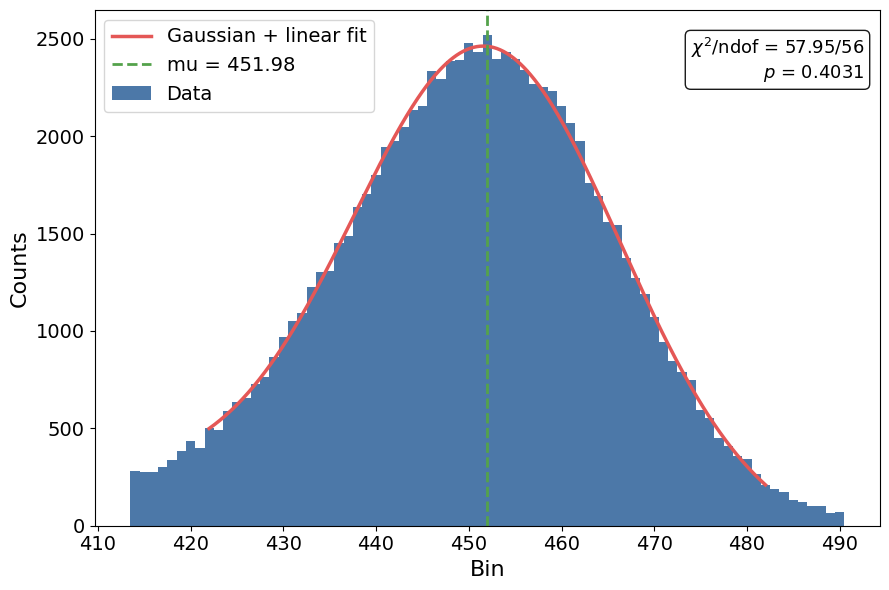

In [32]:
# Pick the candidate index you want to fit
candidate_idx = 5
fit_half_width = 30

candidate_bin = float(cands.candidate_bins[candidate_idx])
fit = fit_local_peak(
    sp.bins,
    sp.counts,
    candidate_bin=candidate_bin,
    fit_half_width=fit_half_width,
    min_p_value=0.01,
)

print(f"Selected candidate index: {candidate_idx}")
print(f"Candidate bin: {candidate_bin:.2f}")
print(f"Fit success: {fit.success}")
print(f"mu = {fit.fit_center:.3f} +/- {fit.fit_center_err:.3f} bins")
print(f"sigma = {fit.sigma:.3f} +/- {fit.sigma_err:.3f} bins")
print(f"chi2/ndof = {fit.chi2_val:.2f}/{fit.ndof}, p = {fit.p_value:.4f}")

left, right = fit.fit_range
xfit = sp.bins[left:right + 1]
yfit = sp.counts[left:right + 1]
xdense = np.linspace(xfit.min(), xfit.max(), 500)
ydense = gaussian_plus_linear(
    xdense,
    fit.amplitude,
    fit.fit_center,
    fit.sigma,
    fit.background_intercept,
    fit.background_slope,
)

# Show some context bins outside the actual fit interval.
plot_pad_bins = 8
plot_left = max(0, left - plot_pad_bins)
plot_right = min(len(sp.bins) - 1, right + plot_pad_bins)
xplot = sp.bins[plot_left:plot_right + 1]
yplot = sp.counts[plot_left:plot_right + 1]

plt.figure()
plt.bar(xplot, yplot, width=1.0, color="#4C78A8", label="Data")
plt.plot(xdense, ydense, color="#E45756", lw=2.5, label="Gaussian + linear fit")
plt.axvline(fit.fit_center, color="#54A24B", ls="--", lw=2, label=f"mu = {fit.fit_center:.2f}")
plt.xlabel("Bin")
plt.ylabel("Counts")
textbox = (
    f"$\\chi^2$/ndof = {fit.chi2_val:.2f}/{fit.ndof}\n"
    f"$p$ = {fit.p_value:.4f}"
)
plt.text(
    0.98,
    0.95,
    textbox,
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    fontsize=13,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="black"),
)
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# Net counts and rate from fitted peak area
# method="gaussian_area" is usually the best default for background-subtracted rate.
rate, rate_err = peak_rate_from_fit(
    fit,
    live_time_s=sp.live_time_s,
    method="gaussian_area",
)

print(f"Live time = {sp.live_time_s:.1f} s")
print(f"Peak rate = {rate:.6f} +/- {rate_err:.6f} counts/s")

Live time = 203.0 s
Peak rate = 418.627806 +/- 7.721911 counts/s
